# 🔍 Análise Exploratória de Dados (EDA)
## Detecção de Anomalias Fiscais — Cadeia de Combustíveis RJ

**TCC MBA Data Science | USP ESALQ**  
**Aluna:** Kátia Rios Nóbrega de Mello  
**Base de referência:** novembro/2025  
**Fontes:** Receita Federal (CNPJ), CEIS, ANP  

---

### Estrutura
1. Configuração e carregamento
2. Visão geral do dataset
3. Análise por situação cadastral
4. Análise por segmento (CNAE)
5. Análise societária
6. Análise financeira (capital social)
7. Análise temporal
8. Correlações entre variáveis
9. Análise do score de risco
10. Síntese dos achados

## 1. Configuração e Carregamento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paleta acadêmica: tons de azul + tracejado vermelho ───
AZUL = {
    'escuro':  '#003366',
    'medio':   '#1a5276',
    'claro':   '#2e86c1',
    'palido':  '#85c1e9',
    'cinza':   '#566573',
}
VERMELHO = '#C0392B'  # usado em tracejados de referência

CORES_RISCO = {
    'Crítico': AZUL['escuro'],
    'Alto':    AZUL['medio'],
    'Médio':   AZUL['claro'],
    'Baixo':   AZUL['palido'],
}

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlecolor'] = AZUL['escuro']
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

OUT_DIR = Path('../outputs/graficos')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Configuração carregada')

✅ Configuração carregada


In [2]:
df = pd.read_parquet('../data/processed/dataset_features_rj.parquet')
print(f'Dataset: {len(df):,} empresas × {df.shape[1]} variáveis')

nomes_curtos = {
    'Comércio varejista de combustíveis (postos)': 'Postos (varejo)',
    'Extração de petróleo e gás natural': 'Extração petróleo/gás',
    'Comércio atacadista de combustíveis': 'Atacado combustíveis',
    'Transporte dutoviário de combustíveis': 'Transporte dutoviário',
    'Fabricação de combustíveis': 'Fabricação combustíveis',
    'Fabricação de produtos do refino de petróleo': 'Refino petróleo',
}

Dataset: 1,520 empresas × 51 variáveis


## 2. Visão Geral do Dataset

In [3]:
cols_desc = ['idade_empresa_dias','anos_operacao','qtd_socios',
             'qtd_filiais','capital_social','max_empresas_por_socio','score_risco_v2']
df[cols_desc].describe().round(2)

,idade_empresa_dias,anos_operacao,qtd_socios,qtd_filiais,capital_social,max_empresas_por_socio,score_risco_v2
count,1520.00,1520.00,1520.00,1520.00,1.520000e+03,1520.00,1520.00
mean,7851.52,21.51,1.86,0.16,4.378716e+06,3.07,4.19
std,6029.37,16.52,1.47,1.52,1.524688e+08,4.47,2.89
min,27.00,0.10,0.00,0.00,0.000000e+00,1.00,0.00
25%,2812.75,7.70,1.00,0.00,0.000000e+00,1.00,2.00
50%,6644.00,18.20,2.00,0.00,0.000000e+00,1.00,3.00
75%,10753.75,29.45,2.00,0.00,0.000000e+00,3.00,6.00
max,25337.00,69.40,18.00,54.00,5.926741e+09,22.00,12.00


In [4]:
print('=' * 50)
print('  RESUMO DO DATASET')
print('=' * 50)
print(f'  Total de empresas:        {len(df):>8,}')
print(f'  Variáveis:                {df.shape[1]:>8}')
print(f'  Empresas ativas:          {(df["situacao_desc"]=="Ativa").sum():>8,}')
print(f'  Empresas inaptas:         {(df["situacao_desc"]=="Inapta").sum():>8,}')
print(f'  Empresas suspensas:       {(df["situacao_desc"]=="Suspensa").sum():>8,}')
print(f'  Capital social médio:     R$ {df["capital_social"].mean():>10,.2f}')
print(f'  Idade média (anos):       {df["anos_operacao"].mean():>8.1f}')
print(f'  Média de sócios:          {df["qtd_socios"].mean():>8.1f}')
print('=' * 50)

  RESUMO DO DATASET
  Total de empresas:           1,520
  Variáveis:                      51
  Empresas ativas:             1,161
  Empresas inaptas:              350
  Empresas suspensas:              9
  Capital social médio:     R$ 4,378,715.57
  Idade média (anos):           21.5
  Média de sócios:               1.9


## 3. Análise por Situação Cadastral

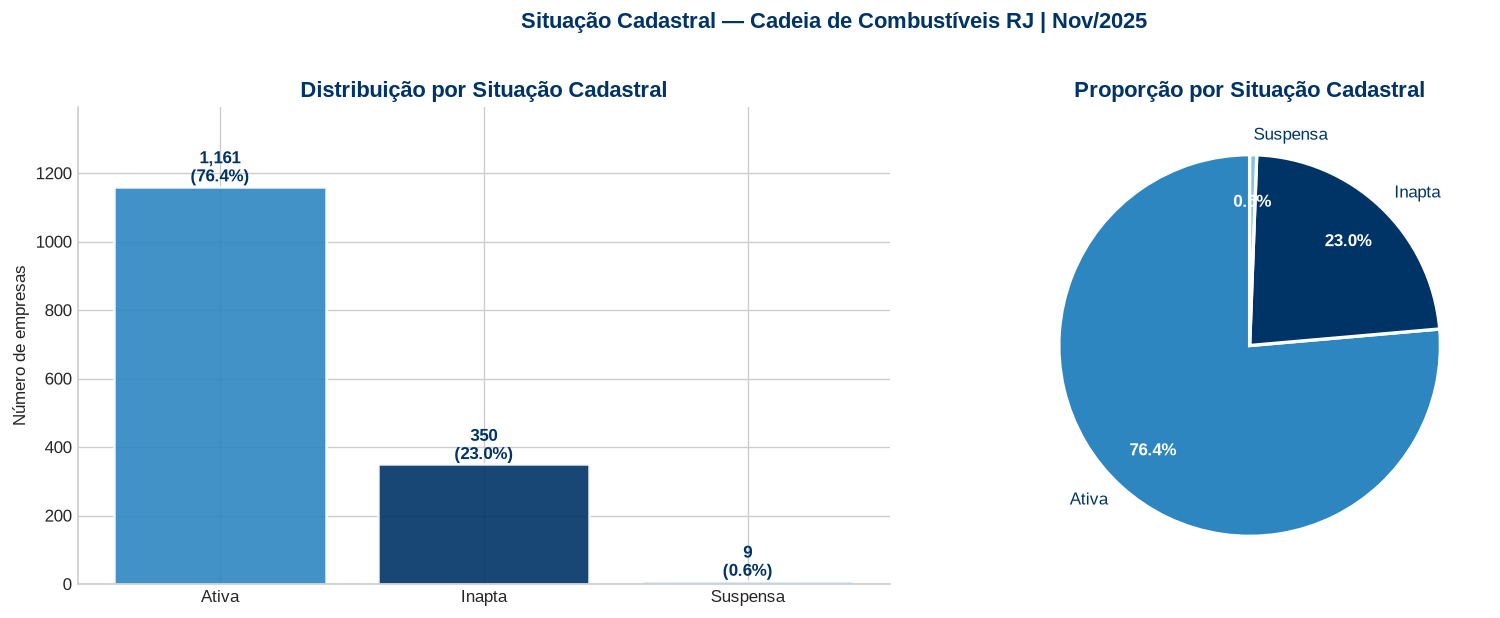

⚠️ 23% de empresas inaptas — elevado para setor regulado pela ANP


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sit = df['situacao_desc'].value_counts().reindex(['Ativa','Inapta','Suspensa'])
cores_sit = [AZUL['claro'], AZUL['escuro'], AZUL['palido']]

bars = axes[0].bar(sit.index, sit.values, color=cores_sit,
                    edgecolor='white', linewidth=1.5, alpha=0.9)
for bar, val in zip(bars, sit.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold', color=AZUL['escuro'])
axes[0].set_title('Distribuição por Situação Cadastral')
axes[0].set_ylabel('Número de empresas')
axes[0].set_ylim(0, sit.max()*1.2)

wedges, texts, autotexts = axes[1].pie(
    sit.values, labels=sit.index, colors=cores_sit,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops={'edgecolor':'white','linewidth':2})
for t in autotexts: t.set_fontweight('bold'); t.set_color('white')
for t in texts: t.set_color(AZUL['escuro'])
axes[1].set_title('Proporção por Situação Cadastral')

plt.suptitle('Situação Cadastral — Cadeia de Combustíveis RJ | Nov/2025',
             fontsize=13, fontweight='bold', color=AZUL['escuro'], y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR/'EDA_01_situacao_cadastral.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('⚠️ 23% de empresas inaptas — elevado para setor regulado pela ANP')

## 4. Análise por Segmento (CNAE)

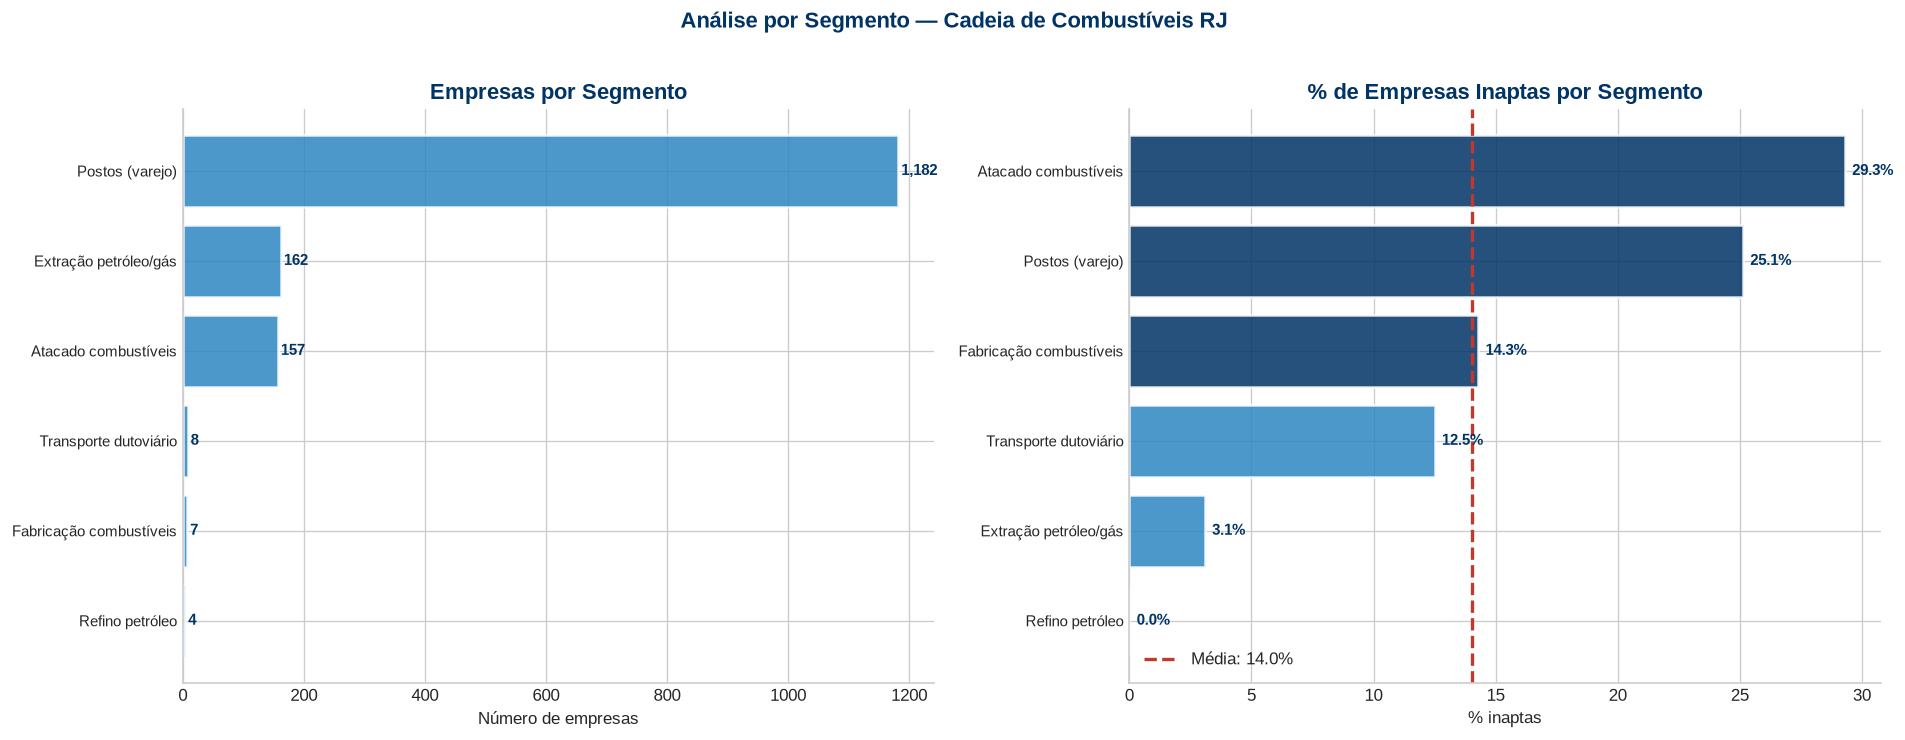

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cnae_counts = df['cnae_descricao'].value_counts()
cnae_counts.index = [nomes_curtos.get(i, i) for i in cnae_counts.index]

axes[0].barh(range(len(cnae_counts)), cnae_counts.values,
              color=AZUL['claro'], alpha=0.85, edgecolor='white', linewidth=1.5)
axes[0].set_yticks(range(len(cnae_counts)))
axes[0].set_yticklabels(cnae_counts.index, fontsize=9)
axes[0].invert_yaxis()
for i, val in enumerate(cnae_counts.values):
    axes[0].text(val+5, i, f'{val:,}', va='center', fontsize=9,
                 fontweight='bold', color=AZUL['escuro'])
axes[0].set_title('Empresas por Segmento')
axes[0].set_xlabel('Número de empresas')

inaptas_cnae = df.groupby('cnae_descricao').apply(
    lambda x: (x['situacao_desc']=='Inapta').mean()*100).sort_values(ascending=True)
inaptas_cnae.index = [nomes_curtos.get(i, i) for i in inaptas_cnae.index]
media = inaptas_cnae.mean()
cores_i = [AZUL['escuro'] if v > media else AZUL['claro'] for v in inaptas_cnae.values]
axes[1].barh(range(len(inaptas_cnae)), inaptas_cnae.values,
              color=cores_i, alpha=0.85, edgecolor='white', linewidth=1.5)
axes[1].set_yticks(range(len(inaptas_cnae)))
axes[1].set_yticklabels(inaptas_cnae.index, fontsize=9)
axes[1].axvline(x=media, color=VERMELHO, linestyle='--', linewidth=2,
                label=f'Média: {media:.1f}%')
for i, val in enumerate(inaptas_cnae.values):
    axes[1].text(val+0.3, i, f'{val:.1f}%', va='center', fontsize=9,
                 fontweight='bold', color=AZUL['escuro'])
axes[1].set_title('% de Empresas Inaptas por Segmento')
axes[1].set_xlabel('% inaptas'); axes[1].legend()

plt.suptitle('Análise por Segmento — Cadeia de Combustíveis RJ',
             fontsize=13, fontweight='bold', color=AZUL['escuro'], y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR/'EDA_02_analise_segmento.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 5. Análise Societária

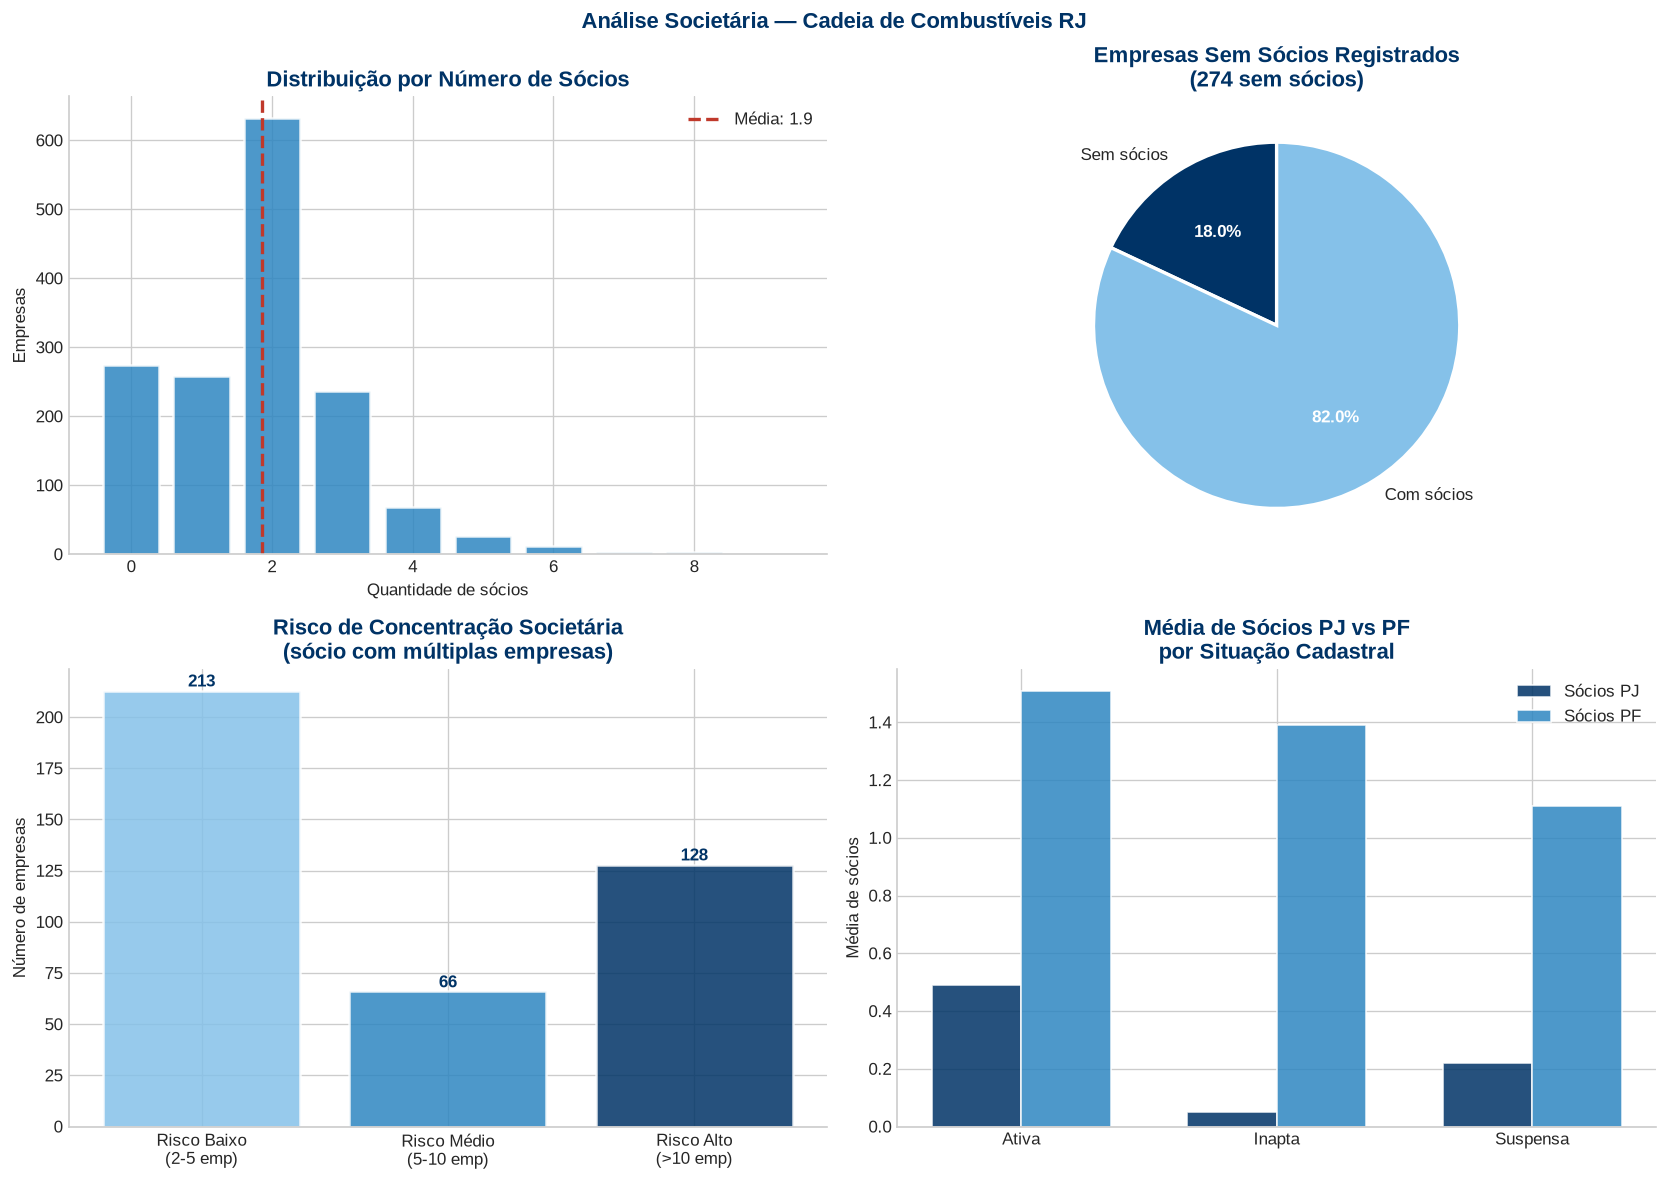


📊 Insights societários:
  • 274 empresas sem sócios (18.0%)
  • 128 empresas com sócio em >10 empresas


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

socios_dist = df['qtd_socios'].value_counts().sort_index().head(10)
axes[0,0].bar(socios_dist.index, socios_dist.values,
               color=AZUL['claro'], alpha=0.85, edgecolor='white', linewidth=1.5)
axes[0,0].axvline(df['qtd_socios'].mean(), color=VERMELHO, linestyle='--',
                   linewidth=2, label=f'Média: {df["qtd_socios"].mean():.1f}')
axes[0,0].set_title('Distribuição por Número de Sócios')
axes[0,0].set_xlabel('Quantidade de sócios'); axes[0,0].set_ylabel('Empresas')
axes[0,0].legend()

sem = [df['sem_socios'].sum(), (df['sem_socios']==0).sum()]
axes[0,1].pie(sem, labels=['Sem sócios','Com sócios'],
               colors=[AZUL['escuro'], AZUL['palido']], autopct='%1.1f%%',
               startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
for t in axes[0,1].texts:
    if '%' in t.get_text(): t.set_color('white'); t.set_fontweight('bold')
axes[0,1].set_title(f'Empresas Sem Sócios Registrados\n({df["sem_socios"].sum():,} sem sócios)')

risco = pd.Series({
    'Risco Baixo\n(2-5 emp)':  df['socio_risco_baixo'].sum(),
    'Risco Médio\n(5-10 emp)': df['socio_risco_medio'].sum(),
    'Risco Alto\n(>10 emp)':   df['socio_risco_alto'].sum(),
})
bars = axes[1,0].bar(risco.index, risco.values,
                      color=[AZUL['palido'],AZUL['claro'],AZUL['escuro']],
                      alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, risco.values):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                   f'{val:,}', ha='center', fontweight='bold', color=AZUL['escuro'])
axes[1,0].set_title('Risco de Concentração Societária\n(sócio com múltiplas empresas)')
axes[1,0].set_ylabel('Número de empresas')

tipo_sit = df.groupby('situacao_desc')[['qtd_socios_pj','qtd_socios_pf']].mean().round(2)
tipo_sit = tipo_sit.reindex([s for s in ['Ativa','Inapta','Suspensa'] if s in tipo_sit.index])
x = np.arange(len(tipo_sit)); w = 0.35
axes[1,1].bar(x-w/2, tipo_sit['qtd_socios_pj'], w, label='Sócios PJ',
               color=AZUL['escuro'], alpha=0.85, edgecolor='white')
axes[1,1].bar(x+w/2, tipo_sit['qtd_socios_pf'], w, label='Sócios PF',
               color=AZUL['claro'], alpha=0.85, edgecolor='white')
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(tipo_sit.index)
axes[1,1].set_title('Média de Sócios PJ vs PF\npor Situação Cadastral')
axes[1,1].set_ylabel('Média de sócios'); axes[1,1].legend()

plt.suptitle('Análise Societária — Cadeia de Combustíveis RJ',
             fontsize=13, fontweight='bold', color=AZUL['escuro'])
plt.tight_layout()
plt.savefig(OUT_DIR/'EDA_03_analise_societaria.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f'\n📊 Insights societários:')
print(f'  • {df["sem_socios"].sum():,} empresas sem sócios ({df["sem_socios"].mean()*100:.1f}%)')
print(f'  • {df["socio_risco_alto"].sum():,} empresas com sócio em >10 empresas')

## 6. Análise Financeira (Capital Social)

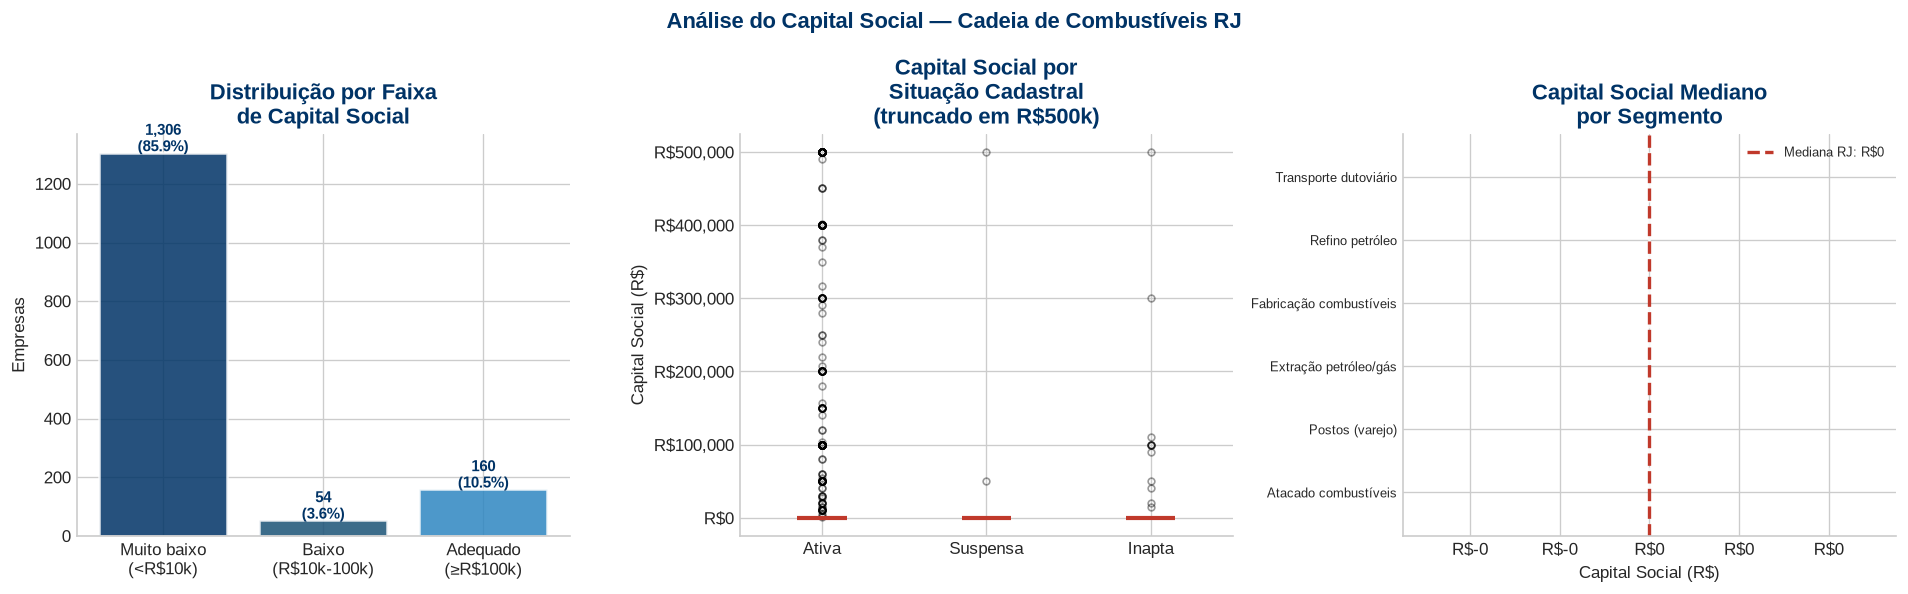


📊 Insights financeiros:
  • 85.9% das empresas têm capital < R$10.000
  • Capital mediano geral: R$0.00


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

faixas = pd.Series({
    'Muito baixo\n(<R$10k)': df['capital_muito_baixo'].sum(),
    'Baixo\n(R$10k-100k)':  df['capital_baixo'].sum(),
    'Adequado\n(≥R$100k)':  df['capital_adequado'].sum(),
})
bars = axes[0].bar(faixas.index, faixas.values,
                    color=[AZUL['escuro'],AZUL['medio'],AZUL['claro']],
                    alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, faixas.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=9, fontweight='bold', color=AZUL['escuro'])
axes[0].set_title('Distribuição por Faixa\nde Capital Social')
axes[0].set_ylabel('Empresas')

dados_box = [df[df['situacao_desc']==s]['capital_social'].clip(upper=500000).values
             for s in ['Ativa','Suspensa','Inapta']]
bp = axes[1].boxplot(dados_box, tick_labels=['Ativa','Suspensa','Inapta'],
                      patch_artist=True, medianprops={'color':VERMELHO,'linewidth':2.5})
for patch, cor in zip(bp['boxes'], [AZUL['claro'],AZUL['medio'],AZUL['escuro']]):
    patch.set_facecolor(cor); patch.set_alpha(0.85)
for el in ['whiskers','caps']:
    for item in bp[el]: item.set_color(AZUL['escuro']); item.set_linewidth(1.5)
for flier in bp['fliers']:
    flier.set(marker='o', color=AZUL['cinza'], alpha=0.4, markersize=4)
axes[1].set_title('Capital Social por\nSituação Cadastral\n(truncado em R$500k)')
axes[1].set_ylabel('Capital Social (R$)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'R${x:,.0f}'))

cap_cnae = df.groupby('cnae_descricao')['capital_social'].median().sort_values()
cap_cnae.index = [nomes_curtos.get(i, i) for i in cap_cnae.index]
axes[2].barh(range(len(cap_cnae)), cap_cnae.values,
              color=AZUL['claro'], alpha=0.85, edgecolor='white', linewidth=1.5)
axes[2].set_yticks(range(len(cap_cnae)))
axes[2].set_yticklabels(cap_cnae.index, fontsize=8)
axes[2].axvline(df['capital_social'].median(), color=VERMELHO, linestyle='--',
                linewidth=2, label=f'Mediana RJ: R${df["capital_social"].median():,.0f}')
axes[2].set_title('Capital Social Mediano\npor Segmento')
axes[2].set_xlabel('Capital Social (R$)'); axes[2].legend(fontsize=8)
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'R${x:,.0f}'))

plt.suptitle('Análise do Capital Social — Cadeia de Combustíveis RJ',
             fontsize=13, fontweight='bold', color=AZUL['escuro'])
plt.tight_layout()
plt.savefig(OUT_DIR/'EDA_04_capital_social.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f'\n📊 Insights financeiros:')
print(f'  • {df["capital_muito_baixo"].mean()*100:.1f}% das empresas têm capital < R$10.000')
print(f'  • Capital mediano geral: R${df["capital_social"].median():,.2f}')

## 7. Análise Temporal

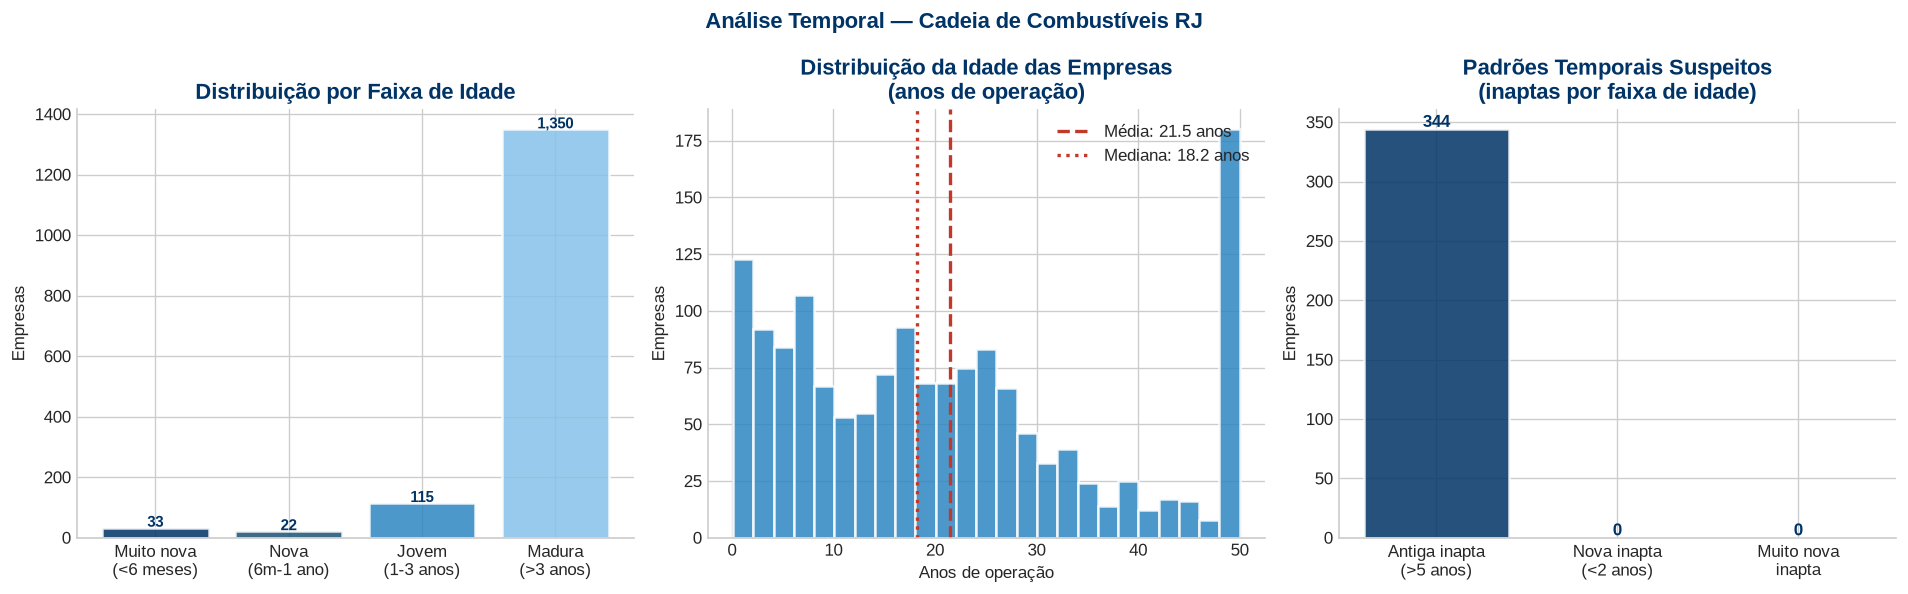


📊 Insights temporais:
  • 344 empresas com >5 anos e inaptas
  • Idade média do setor: 21.5 anos


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

faixas_i = pd.Series({
    'Muito nova\n(<6 meses)': df['empresa_muito_nova'].sum(),
    'Nova\n(6m-1 ano)':       df['empresa_nova'].sum(),
    'Jovem\n(1-3 anos)':      df['empresa_jovem'].sum(),
    'Madura\n(>3 anos)':      df['empresa_madura'].sum(),
})
bars = axes[0].bar(faixas_i.index, faixas_i.values,
                    color=[AZUL['escuro'],AZUL['medio'],AZUL['claro'],AZUL['palido']],
                    alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, faixas_i.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=9,
                 color=AZUL['escuro'])
axes[0].set_title('Distribuição por Faixa de Idade')
axes[0].set_ylabel('Empresas')

axes[1].hist(df['anos_operacao'].clip(upper=50), bins=25,
              color=AZUL['claro'], edgecolor='white', linewidth=1.5, alpha=0.85)
axes[1].axvline(df['anos_operacao'].mean(), color=VERMELHO, linestyle='--',
                linewidth=2, label=f'Média: {df["anos_operacao"].mean():.1f} anos')
axes[1].axvline(df['anos_operacao'].median(), color=VERMELHO, linestyle=':',
                linewidth=2, label=f'Mediana: {df["anos_operacao"].median():.1f} anos')
axes[1].set_title('Distribuição da Idade das Empresas\n(anos de operação)')
axes[1].set_xlabel('Anos de operação'); axes[1].set_ylabel('Empresas')
axes[1].legend()

padroes = pd.Series({
    'Antiga inapta\n(>5 anos)': df['antiga_inapta'].sum(),
    'Nova inapta\n(<2 anos)':   df['nova_inapta'].sum(),
    'Muito nova\ninapta':        ((df['empresa_muito_nova']==1)&(df['inapta']==1)).sum(),
})
axes[2].bar(padroes.index, padroes.values,
             color=[AZUL['escuro'],AZUL['claro'],AZUL['palido']],
             alpha=0.85, edgecolor='white', linewidth=1.5)
for i, (l, val) in enumerate(padroes.items()):
    axes[2].text(i, val+2, f'{val:,}', ha='center',
                  fontweight='bold', color=AZUL['escuro'])
axes[2].set_title('Padrões Temporais Suspeitos\n(inaptas por faixa de idade)')
axes[2].set_ylabel('Empresas')

plt.suptitle('Análise Temporal — Cadeia de Combustíveis RJ',
             fontsize=13, fontweight='bold', color=AZUL['escuro'])
plt.tight_layout()
plt.savefig(OUT_DIR/'EDA_05_analise_temporal.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f'\n📊 Insights temporais:')
print(f'  • {df["antiga_inapta"].sum():,} empresas com >5 anos e inaptas')
print(f'  • Idade média do setor: {df["anos_operacao"].mean():.1f} anos')

## 8. Correlações entre Variáveis

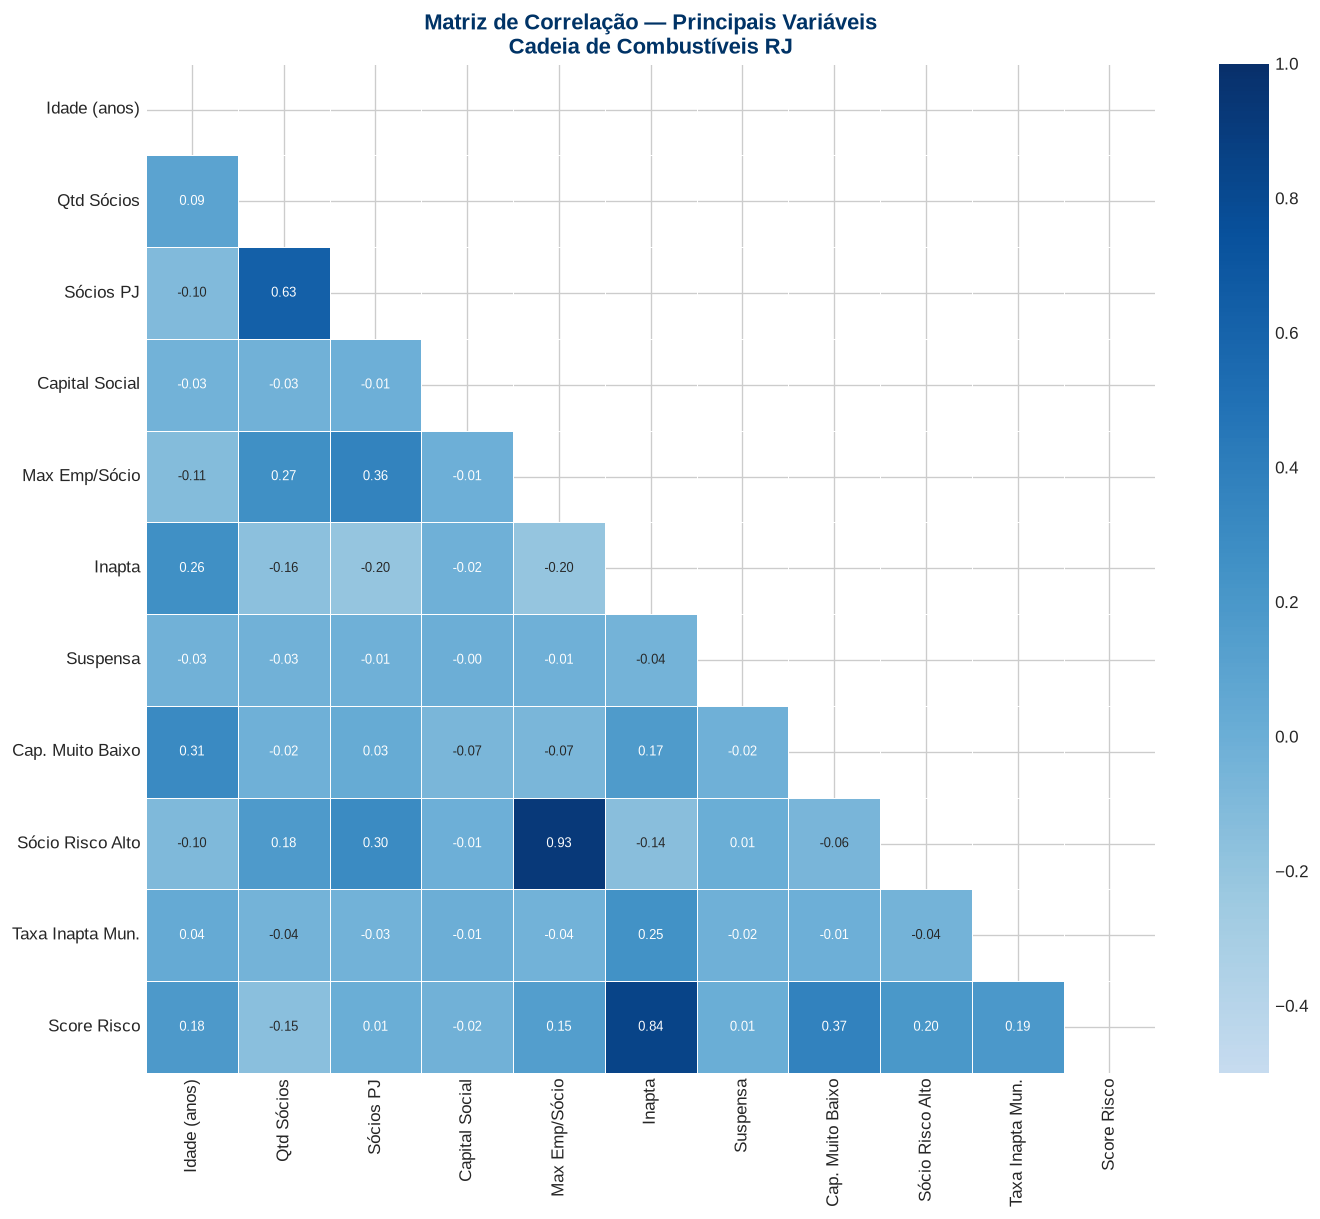


📊 Correlação com Score de Risco:
Qtd Sócios         -0.149366
Capital Social     -0.023645
Sócios PJ           0.005890
Suspensa            0.006815
Max Emp/Sócio       0.149718
Idade (anos)        0.184857
Taxa Inapta Mun.    0.189128
Sócio Risco Alto    0.197536
Cap. Muito Baixo    0.367234
Inapta              0.844689


In [10]:
cols_corr = ['anos_operacao','qtd_socios','qtd_socios_pj','capital_social',
             'max_empresas_por_socio','inapta','suspensa',
             'capital_muito_baixo','socio_risco_alto',
             'taxa_inapta_municipio','score_risco_v2']
cols_corr = [c for c in cols_corr if c in df.columns]
nomes = {
    'anos_operacao':'Idade (anos)', 'qtd_socios':'Qtd Sócios',
    'qtd_socios_pj':'Sócios PJ', 'capital_social':'Capital Social',
    'max_empresas_por_socio':'Max Emp/Sócio', 'inapta':'Inapta',
    'suspensa':'Suspensa', 'capital_muito_baixo':'Cap. Muito Baixo',
    'socio_risco_alto':'Sócio Risco Alto',
    'taxa_inapta_municipio':'Taxa Inapta Mun.', 'score_risco_v2':'Score Risco'
}
corr = df[cols_corr].rename(columns=nomes).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Blues',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size':8}, vmin=-0.5, vmax=1)
ax.set_title('Matriz de Correlação — Principais Variáveis\nCadeia de Combustíveis RJ',
             fontsize=13, fontweight='bold', color=AZUL['escuro'])
plt.tight_layout()
plt.savefig(OUT_DIR/'EDA_06_correlacao.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

corr_score = corr['Score Risco'].drop('Score Risco').sort_values()
print('\n📊 Correlação com Score de Risco:')
print(corr_score.to_string())

## 9. Análise do Score de Risco

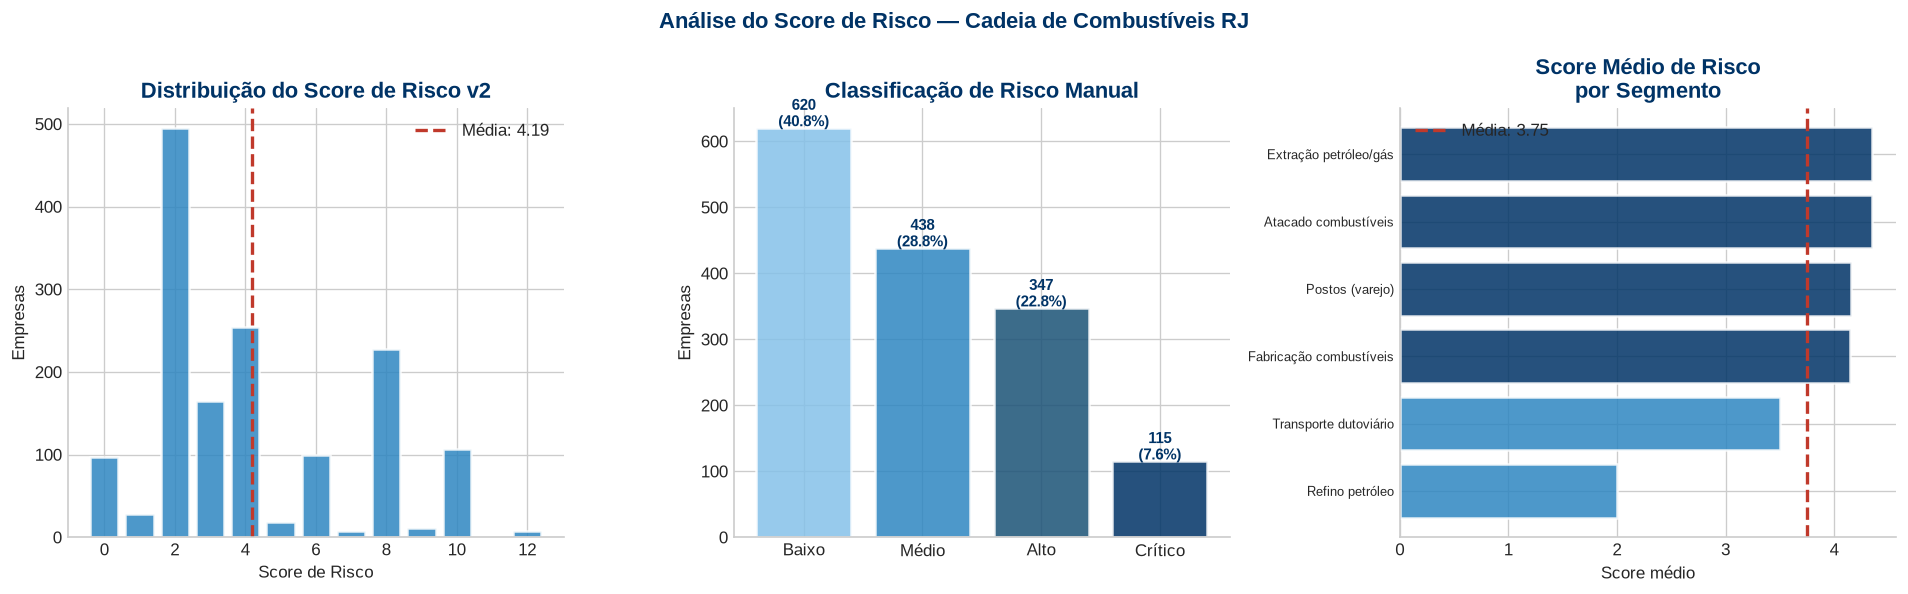

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

score_counts = df['score_risco_v2'].value_counts().sort_index()
axes[0].bar(score_counts.index, score_counts.values,
             color=AZUL['claro'], alpha=0.85, edgecolor='white', linewidth=1.5)
axes[0].axvline(df['score_risco_v2'].mean(), color=VERMELHO, linestyle='--',
                linewidth=2, label=f'Média: {df["score_risco_v2"].mean():.2f}')
axes[0].set_title('Distribuição do Score de Risco v2')
axes[0].set_xlabel('Score de Risco'); axes[0].set_ylabel('Empresas')
axes[0].legend()

ordem_c = ['Baixo','Médio','Alto','Crítico']
cl_counts = df['classe_risco'].value_counts().reindex(
    [c for c in ordem_c if c in df['classe_risco'].cat.categories])
cores_c = [AZUL['palido'],AZUL['claro'],AZUL['medio'],AZUL['escuro']]
bars = axes[1].bar(cl_counts.index, cl_counts.values, color=cores_c,
                    alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, cl_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=9, fontweight='bold', color=AZUL['escuro'])
axes[1].set_title('Classificação de Risco Manual'); axes[1].set_ylabel('Empresas')

score_cnae = df.groupby('cnae_descricao')['score_risco_v2'].mean().sort_values()
score_cnae.index = [nomes_curtos.get(i, i) for i in score_cnae.index]
media_s = score_cnae.mean()
cores_sc = [AZUL['escuro'] if v > media_s else AZUL['claro'] for v in score_cnae.values]
axes[2].barh(range(len(score_cnae)), score_cnae.values,
              color=cores_sc, alpha=0.85, edgecolor='white', linewidth=1.5)
axes[2].set_yticks(range(len(score_cnae)))
axes[2].set_yticklabels(score_cnae.index, fontsize=8)
axes[2].axvline(media_s, color=VERMELHO, linestyle='--', linewidth=2,
                label=f'Média: {media_s:.2f}')
axes[2].set_title('Score Médio de Risco\npor Segmento')
axes[2].set_xlabel('Score médio'); axes[2].legend()

plt.suptitle('Análise do Score de Risco — Cadeia de Combustíveis RJ',
             fontsize=13, fontweight='bold', color=AZUL['escuro'])
plt.tight_layout()
plt.savefig(OUT_DIR/'EDA_07_score_risco.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 10. Síntese dos Achados

In [12]:
print('=' * 65)
print('  SÍNTESE DA ANÁLISE EXPLORATÓRIA')
print('  Cadeia de Combustíveis RJ | Nov/2025')
print('=' * 65)
print(f'\n📌 PERFIL GERAL:')
print(f'  • {len(df):,} empresas em 6 segmentos da cadeia')
print(f'  • Postos de varejo: {(df["cnae_4dig"]=="4731").sum():,} unidades ({(df["cnae_4dig"]=="4731").mean()*100:.1f}%)')
print(f'  • Idade média: {df["anos_operacao"].mean():.1f} anos')
print(f'\n⚠️ INDICADORES DE ANOMALIA:')
print(f'  • {df["inapta"].mean()*100:.1f}% das empresas estão inaptas')
print(f'  • {df["capital_muito_baixo"].mean()*100:.1f}% têm capital < R$10.000')
print(f'  • {df["sem_socios"].mean()*100:.1f}% sem sócios registrados')
print(f'  • {df["socio_risco_alto"].mean()*100:.1f}% com sócio em >10 empresas')
print(f'\n📊 SCORE DE RISCO:')
print(f'  • Score médio: {df["score_risco_v2"].mean():.2f} (escala 0-12)')
for classe in ['Baixo','Médio','Alto','Crítico']:
    qtd = (df['classe_risco'] == classe).sum()
    print(f'  • {classe:<10}: {qtd:>5,} ({qtd/len(df)*100:.1f}%)')
print('=' * 65)

  SÍNTESE DA ANÁLISE EXPLORATÓRIA
  Cadeia de Combustíveis RJ | Nov/2025

📌 PERFIL GERAL:
  • 1,520 empresas em 6 segmentos da cadeia
  • Postos de varejo: 1,182 unidades (77.8%)
  • Idade média: 21.5 anos

⚠️ INDICADORES DE ANOMALIA:
  • 23.0% das empresas estão inaptas
  • 85.9% têm capital < R$10.000
  • 18.0% sem sócios registrados
  • 8.4% com sócio em >10 empresas

📊 SCORE DE RISCO:
  • Score médio: 4.19 (escala 0-12)
  • Baixo     :   620 (40.8%)
  • Médio     :   438 (28.8%)
  • Alto      :   347 (22.8%)
  • Crítico   :   115 (7.6%)
